# Projekt

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


In [53]:
kolumny = [
        "id", "age", "year", "sex", "glang", "part", "job", "stud_h", "health",
        "psyt", "jspe", "qcae_cog", "qcae_aff", "amsp", "erec_mean", "cesd",
        "stai_t", "mbi_ex", "mbi_cy", "mbi_ea"
    ]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

def load_mental_health_data():

    path = pathlib.Path("Data Carrard et al. 2022 MedTeach.csv")
    
    # Wczytanie danych z zachowaniem oryginalnych nagłówków
    df = pd.read_csv(path)
    
    # Ustawienie 'id' jako indeksu
    df.set_index("id", inplace=True)


    # Standardowy punkt odcięcia (cut-off) dla skali CES-D wynosi 16.
    # Wynik cesd >= 16 wskazuje na istotne symptomy depresyjne (ryzyko depresji).
    # Tworzymy NOWĄ kolumnę 'cesd_risk', pozostawiając oryginalne 'cesd' bez zmian.

    df['cesd_risk'] = (df['cesd'] >= 16).astype(int)

    # Instrukcja zwracająca kompletny i zmodyfikowany DataFrame
    return df

# Wybór zbioru danych i wywołanie poprawionej funkcji
df = load_mental_health_data()

### W dalszej części cesd nie będzie używane na rzecz cesd_risk

In [54]:
codebook = pd.read_csv("Codebook Carrard et al. 2022 MedTeach.csv", sep=";", engine="python")
print("Kształt zbioru:", df.shape)
print("Kolumny:")
print(df.columns.tolist())
display(codebook[["Variable Name", "Variable Label", "Variable Scale"]])

Kształt zbioru: (886, 20)
Kolumny:
['age', 'year', 'sex', 'glang', 'part', 'job', 'stud_h', 'health', 'psyt', 'jspe', 'qcae_cog', 'qcae_aff', 'amsp', 'erec_mean', 'cesd', 'stai_t', 'mbi_ex', 'mbi_cy', 'mbi_ea', 'cesd_risk']


,Variable Name,Variable Label,Variable Scale
0,id,Participants ID number,string
1,age,age at questionnaire 20-21,numeric
2,year,CURICULUM YEAR : In which curriculum year are ...,1=Bmed1; 2=Bmed2; 3=Bmed3; 4=Mmed1; 5=Mmed2; 6...
3,sex,GENDER : To which gender do you identify the m...,1=Man; 2=Woman; 3=Non-binary
4,glang,MOTHER TONGUE: What is your mother tongue?,1=French; 15=German; 20=English; 37=Arab; 51=B...
5,part,PARTNERSHIP STATUS : Do you have a partner?,0=No; 1=Yes
6,job,HAVING A JOB : Do you have a paid job?,0=No; 1=Yes
7,stud_h,"HOURS OF STUDY PER WEEK : On average, how many...",NaN
8,health,SATISFACTION WITH HEALTH : How satisfied are y...,1=Verydissatisfied; 2=Dissatisfied; 3=Neithers...
9,psyt,PSYCHOTHERAPY LAST YEAR : During the last 12 m...,0=No; 1=Yes


W 7 punkcie NaN oznacza pytanie do ankietowanych odnośnie ilości godzin w pracy

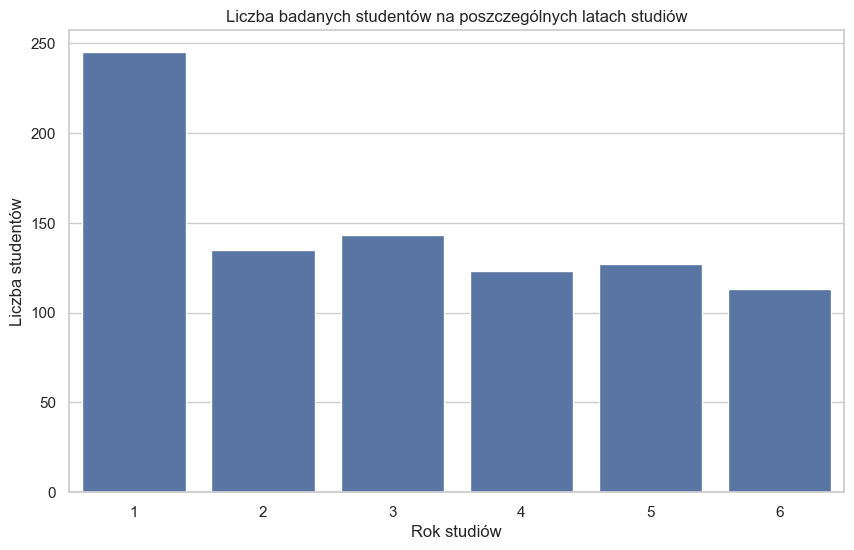

In [55]:
plt.figure()
sns.countplot(data=df, x="year")
plt.title("Liczba badanych studentów na poszczególnych latach studiów")
plt.xlabel("Rok studiów")
plt.ylabel("Liczba studentów")
plt.show()

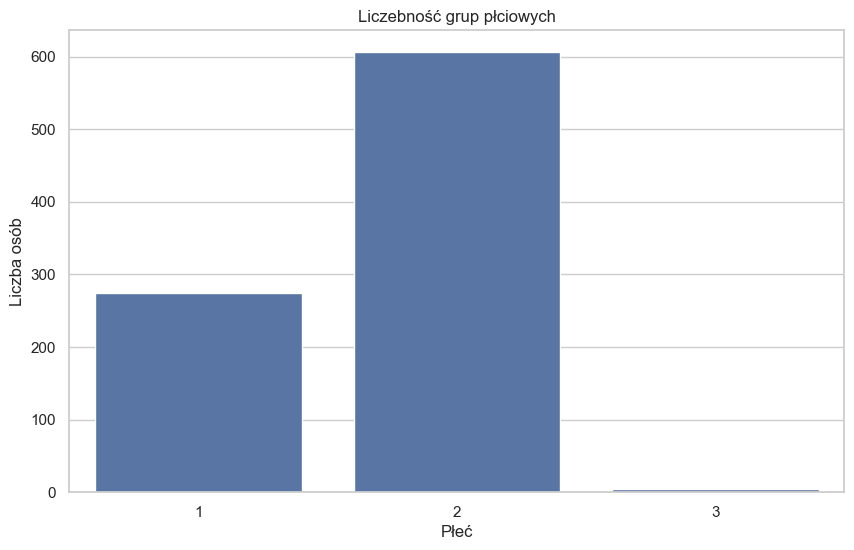

In [56]:
plt.figure()
sns.countplot(data=df, x="sex")
plt.title("Liczebność grup płciowych")
plt.xlabel("Płeć")
plt.ylabel("Liczba osób")
plt.show()

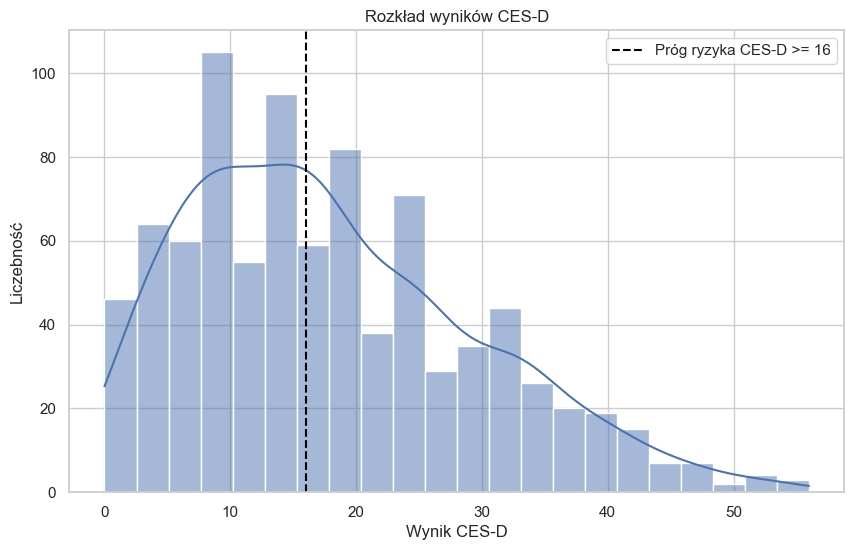

In [57]:
plt.figure()
sns.histplot(data=df, x="cesd", kde=True, bins=22)
plt.axvline(16, color="black", linestyle="--", label="Próg ryzyka CES-D >= 16")
plt.title("Rozkład wyników CES-D")
plt.xlabel("Wynik CES-D")
plt.ylabel("Liczebność")
plt.legend()
plt.show()

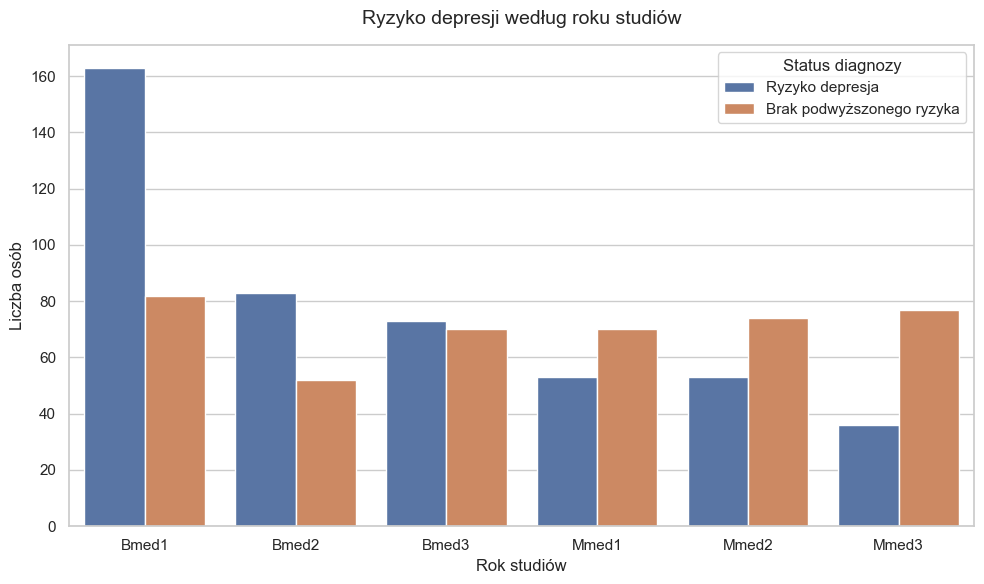

In [58]:
year_map = {1: "Bmed1", 2: "Bmed2", 3: "Bmed3", 4: "Mmed1", 5: "Mmed2", 6: "Mmed3"}
risk_map = {0: "Brak podwyższonego ryzyka", 1: "Ryzyko depresja"}

plt.figure()
sns.countplot(
    x=df["year"].map(year_map),               
    hue=df["cesd_risk"].map(risk_map),        
    order=["Bmed1", "Bmed2", "Bmed3", "Mmed1", "Mmed2", "Mmed3"]
)

plt.title("Ryzyko depresji według roku studiów", fontsize=14, pad=15)
plt.xlabel("Rok studiów", fontsize=12)
plt.ylabel("Liczba osób", fontsize=12)
plt.legend(title="Status diagnozy")
plt.tight_layout()
plt.show()

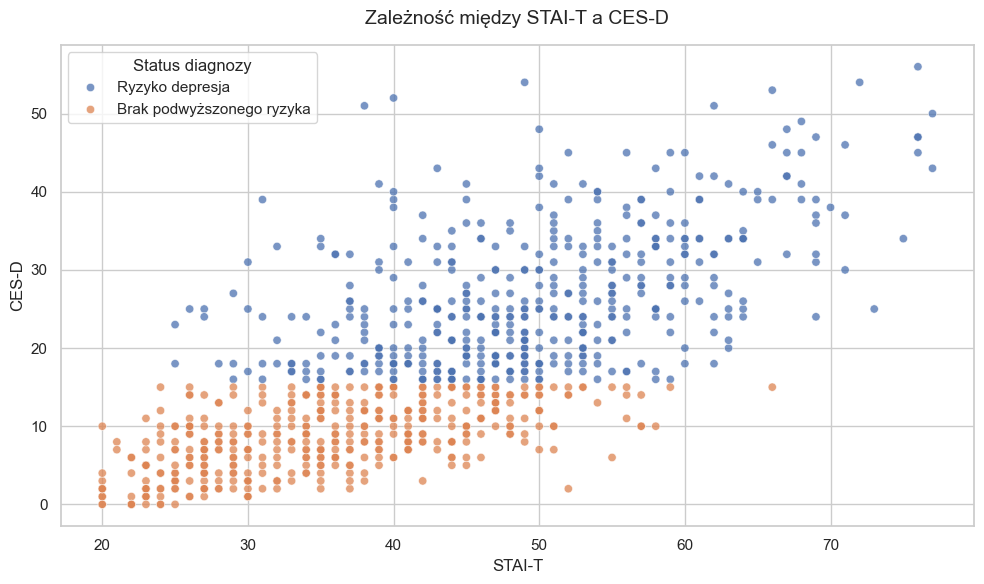

In [59]:
plt.figure()
sns.scatterplot(
    data=df, 
    x="stai_t", 
    y="cesd", 
    hue=df["cesd_risk"].map(risk_map), 
    alpha=0.75
)

plt.title("Zależność między STAI-T a CES-D", fontsize=14, pad=15)
plt.xlabel("STAI-T", fontsize=12)
plt.ylabel("CES-D", fontsize=12)
plt.legend(title="Status diagnozy")
plt.tight_layout()
plt.show()

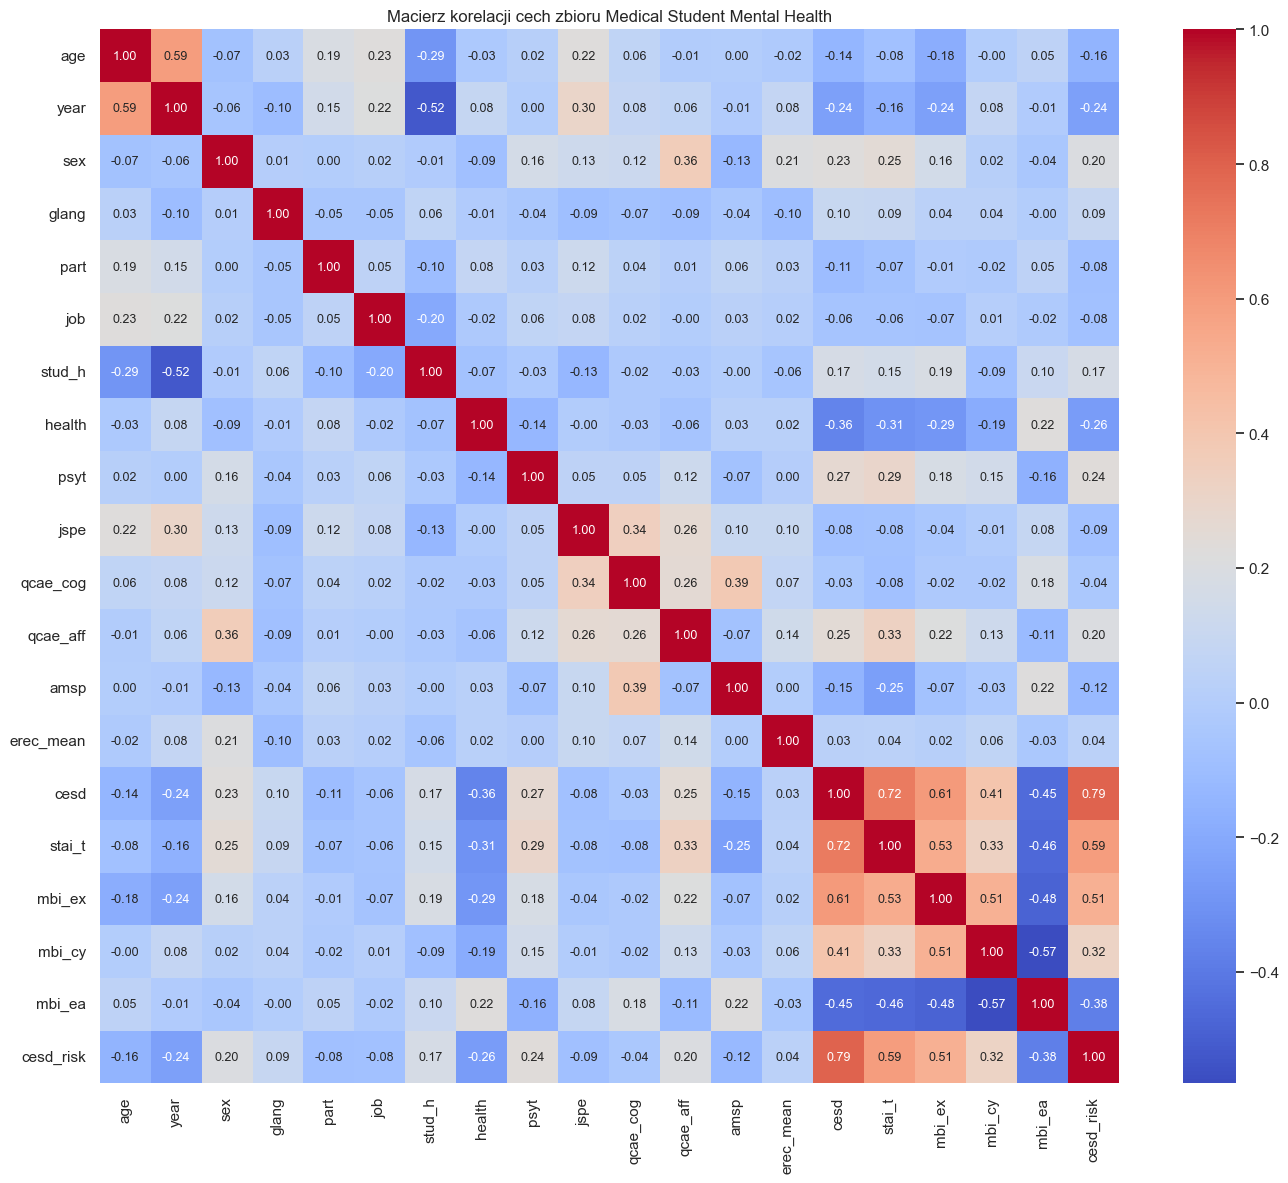

In [60]:
plt.figure(figsize=(14, 12))

# Wybieramy tylko kolumny numeryczne do korelacji
numeric_df = df.apply(pd.to_numeric, errors='coerce')

# Rysowanie mapy ciepła (Heatmap)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 9})
plt.title("Macierz korelacji cech zbioru Medical Student Mental Health", fontsize=12)
plt.tight_layout()
plt.show()

## Regresja Logistyczna

In [61]:
X = df[["age", "year", "sex", "glang", "part", "job", "stud_h", "health",
        "psyt", "jspe", "qcae_cog", "qcae_aff", "amsp", "erec_mean",
        "stai_t", "mbi_ex", "mbi_cy", "mbi_ea"]]
y = df['cesd_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Wyświetlenie statystyk (Poprawka: używamy .iloc dla DataFrame)
print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set:     {X_test_scaled.shape[0]} samples")

# Wypisywanie przedziałów zeskalowanych wartości
print(f"{'Cecha':<15} | {'Zakres przed skalowaniem':<25} | {'Zakres po skalowaniu'}")
print("-" * 75)

for i, col_name in enumerate(X_train.columns):
    # Dane przed skalowaniem (z DataFrame X_train)
    orig_min = X_train.iloc[:, i].min()
    orig_max = X_train.iloc[:, i].max()
    
    # Dane po skalowaniu (z tablicy numpy X_train_scaled)
    scaled_min = X_train_scaled[:, i].min()
    scaled_max = X_train_scaled[:, i].max()
    
    print(f"{col_name:<15} |      [{orig_min:>6.1f}, {orig_max:>6.1f}]     |      [{scaled_min:>6.2f}, {scaled_max:>6.2f}]")

Training set: 708 samples
Test set:     178 samples
Cecha           | Zakres przed skalowaniem  | Zakres po skalowaniu
---------------------------------------------------------------------------
age             |      [  17.0,   44.0]     |      [ -1.66,   6.67]
year            |      [   1.0,    6.0]     |      [ -1.18,   1.67]
sex             |      [   1.0,    3.0]     |      [ -1.47,   2.80]
glang           |      [   1.0,  121.0]     |      [ -0.42,   3.25]
part            |      [   0.0,    1.0]     |      [ -1.14,   0.88]
job             |      [   0.0,    1.0]     |      [ -0.73,   1.37]
stud_h          |      [   0.0,   70.0]     |      [ -1.61,   2.82]
health          |      [   1.0,    5.0]     |      [ -2.62,   1.15]
psyt            |      [   0.0,    1.0]     |      [ -0.54,   1.87]
jspe            |      [  67.0,  125.0]     |      [ -4.50,   2.13]
qcae_cog        |      [  38.0,   76.0]     |      [ -3.19,   2.69]
qcae_aff        |      [  18.0,   47.0]     |      [ -3.1

In [62]:
model = LogisticRegression(random_state=42, max_iter=5000)
model.fit(X_train_scaled, y_train)

# Tworzenie predykcji
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

# Ewaluacja
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print(f"\nTraining accuracy: {train_acc:.2%}")
print(f"Test accuracy:     {test_acc:.2%}")


Training accuracy: 83.05%
Test accuracy:     78.65%


In [63]:
def binary_cross_entropy(y_true, y_pred_prob):
    eps = 1e-15
    y_pred_prob = np.clip(y_pred_prob, eps, 1 - eps)
    loss = -np.mean(y_true * np.log(y_pred_prob) + (1 - y_true) * np.log(1 - y_pred_prob))
    return loss

# Praktyczne zastosowanie: Obliczanie straty wytrenowanego modelu
# Zakładamy, że 'model' to regresja logistyczna wytrenowana wcześniej
y_test_probs = model.predict_proba(X_test_scaled)[:, 1]

# Obliczamy stratę dla zbioru testowego
final_loss = binary_cross_entropy(y_test, y_test_probs)

print(f"Ostateczna strata (Log Loss) na zbiorze testowym: {final_loss:.4f}")

Ostateczna strata (Log Loss) na zbiorze testowym: 0.4470


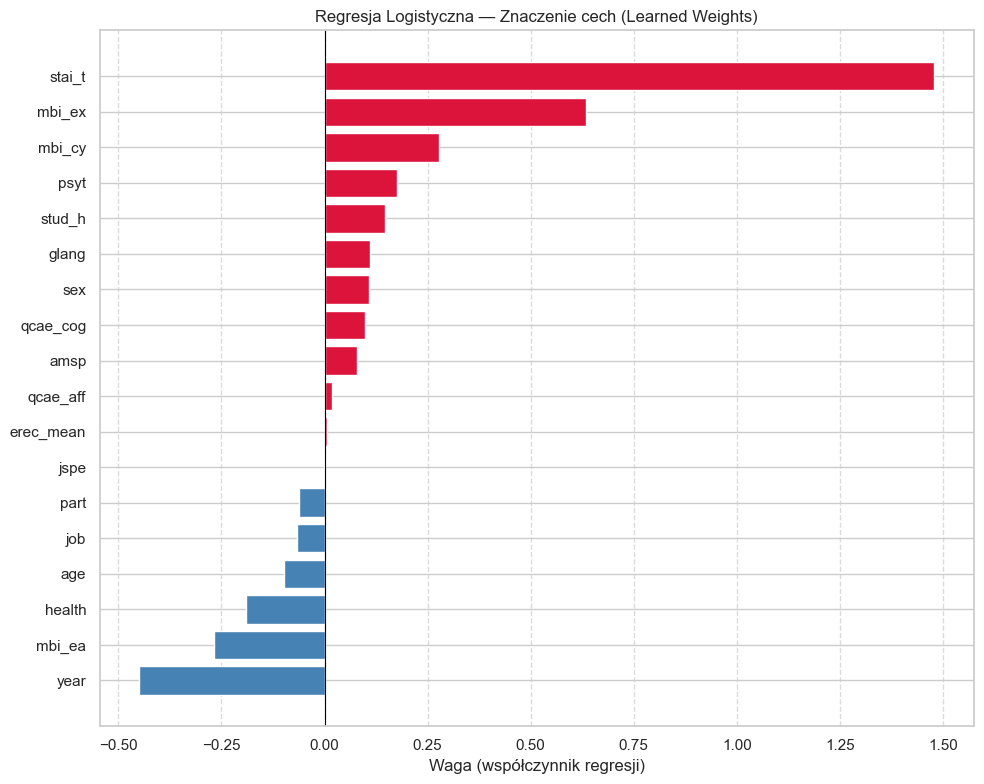


Punkt przecięcia (Intercept/Bias): 0.1642


In [64]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_[0]
}).sort_values('Weight')

plt.figure(figsize=(10, 8))

# Kolory: czerwony dla dodatnich (podnoszą ryzyko), niebieski dla ujemnych (obniżają)
colors = ['steelblue' if w < 0 else 'crimson' for w in coef_df['Weight']]

plt.barh(coef_df['Feature'], coef_df['Weight'], color=colors)
plt.xlabel('Waga (współczynnik regresji)')
plt.title('Regresja Logistyczna — Znaczenie cech (Learned Weights)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\nPunkt przecięcia (Intercept/Bias): {model.intercept_[0]:.4f}")

In [65]:
print("=== Szczegółowy Raport Klasyfikacji Regresji Logistycznej ===\n")
print(classification_report(y_test, y_pred, target_names=['Brak depresji', 'Depresja']))

=== Szczegółowy Raport Klasyfikacji Regresji Logistycznej ===

               precision    recall  f1-score   support

Brak depresji       0.77      0.79      0.78        84
     Depresja       0.80      0.79      0.80        94

     accuracy                           0.79       178
    macro avg       0.79      0.79      0.79       178
 weighted avg       0.79      0.79      0.79       178



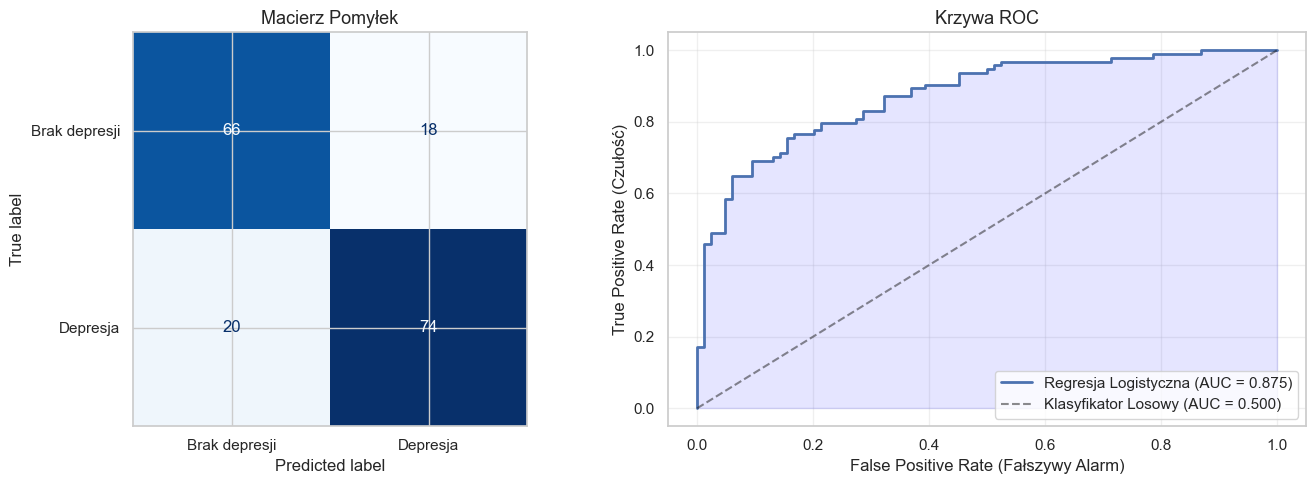


Wynik AUC = 0.875


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Confusion Matrix (Macierz Pomyłek)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Brak depresji', 'Depresja'])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Macierz Pomyłek', fontsize=13)

# Wykres 2: ROC Curve (Krzywa ROC)
# Wyliczamy prawdopodobieństwa dla klasy "Depresja" (indeks 1)
y_scores = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'Regresja Logistyczna (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Klasyfikator Losowy (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[1].set_xlabel('False Positive Rate (Fałszywy Alarm)')
axes[1].set_ylabel('True Positive Rate (Czułość)')
axes[1].set_title('Krzywa ROC', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nWynik AUC = {roc_auc:.3f}")

## MLP

In [67]:
print('Rozmiar zbioru treningowego:', X_train.shape)
print('Rozmiar zbioru testowego:', X_test.shape)

Rozmiar zbioru treningowego: (708, 18)
Rozmiar zbioru testowego: (178, 18)


In [68]:
categorical_features = ['year', 'sex', 'glang', 'part', 'job', 'health', 'psyt']
numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print('Zmienne liczbowe:', numeric_features)
print('Zmienne kategoryczne:', categorical_features)

Zmienne liczbowe: ['age', 'stud_h', 'jspe', 'qcae_cog', 'qcae_aff', 'amsp', 'erec_mean', 'stai_t', 'mbi_ex', 'mbi_cy', 'mbi_ea']
Zmienne kategoryczne: ['year', 'sex', 'glang', 'part', 'job', 'health', 'psyt']


In [69]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20
)

# 2. Tworzenie prostego Pipeline (skalowanie/preprocessing + model)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', mlp)
])

In [70]:
pipeline.fit(X_train, y_train)

# Prognozy klas (0 lub 1) oraz prawdopodobieństw (potrzebne do AUC)
y_pred = pipeline.predict(X_test)
y_probs = pipeline.predict_proba(X_test)[:, 1]

# Obliczanie metryk klasyfikacji binarnej
results_clf = pd.DataFrame({
    'Metryka': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC Score'],
    'Wartość': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_probs)
    ]
})

display(results_clf)
print("=== Szczegółowy Raport Klasyfikacji MLP ===\n")
print(classification_report(y_test, y_pred, target_names=['Brak depresji', 'Depresja']))

,Metryka,Wartość
0,Accuracy,0.758427
1,Precision,0.738318
2,Recall,0.840426
3,F1-Score,0.786070
4,AUC Score,0.876393


=== Szczegółowy Raport Klasyfikacji MLP ===

               precision    recall  f1-score   support

Brak depresji       0.79      0.67      0.72        84
     Depresja       0.74      0.84      0.79        94

     accuracy                           0.76       178
    macro avg       0.76      0.75      0.75       178
 weighted avg       0.76      0.76      0.76       178



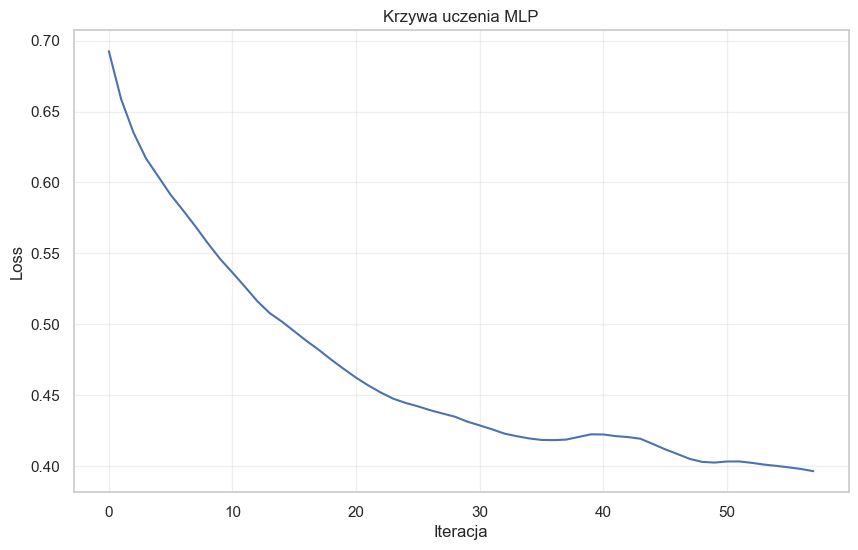

Liczba wykonanych iteracji: 58


In [71]:
mlp_model = pipeline.named_steps['model']

plt.figure()
plt.plot(mlp_model.loss_curve_)
plt.title('Krzywa uczenia MLP')
plt.xlabel('Iteracja')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

print('Liczba wykonanych iteracji:', mlp_model.n_iter_)

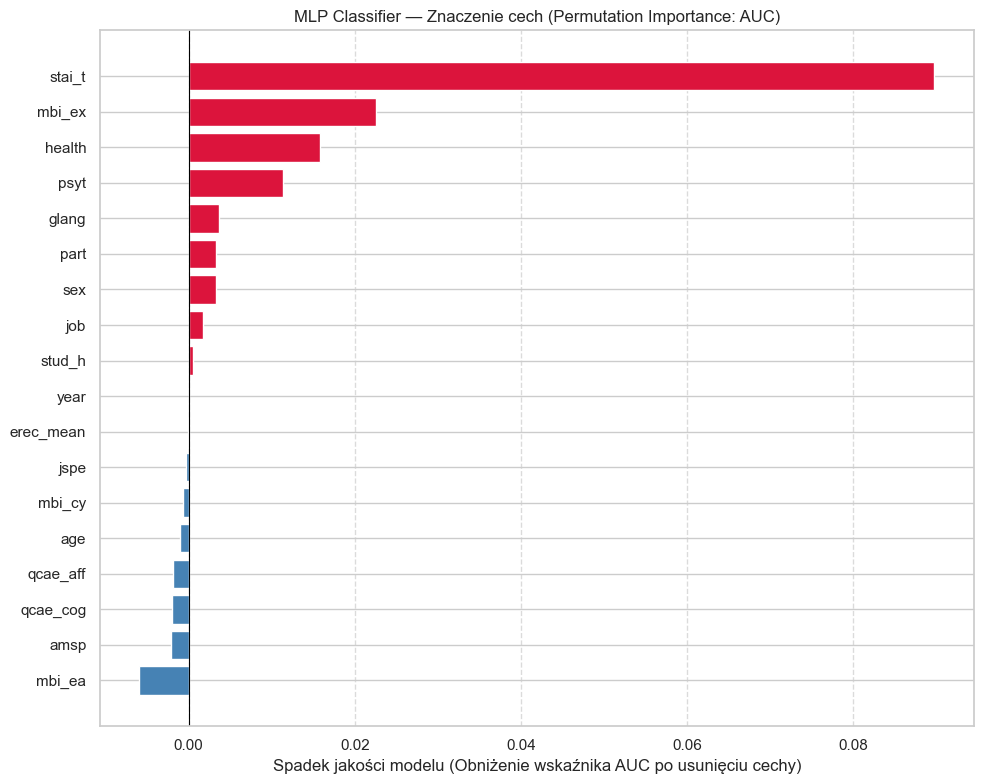


Wyjściowy wyraz wolny (Output Layer Bias): 0.1483


In [72]:
importance = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'  # Zmiana metryki na odpowiednią dla klasyfikacji!
)

# Tworzenie DataFrame (sortujemy od najmniej ważnych/szkodliwych do najważniejszych)
mlp_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': importance.importances_mean
}).sort_values('Importance')

# Rysowanie wykresu słupkowego
plt.figure(figsize=(10, 8))

# Kolory: crimson dla dodatnich (ważne cechy), steelblue dla ujemnych (szum)
colors = ['steelblue' if w < 0 else 'crimson' for w in mlp_importance_df['Importance']]

plt.barh(mlp_importance_df['Feature'], mlp_importance_df['Importance'], color=colors)
plt.xlabel('Spadek jakości modelu (Obniżenie wskaźnika AUC po usunięciu cechy)')
plt.title('MLP Classifier — Znaczenie cech (Permutation Importance: AUC)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Wyciągnięcie Biasu warstwy wyjściowej
mlp_model = pipeline.named_steps['model']
print(f"\nWyjściowy wyraz wolny (Output Layer Bias): {mlp_model.intercepts_[-1][0]:.4f}")

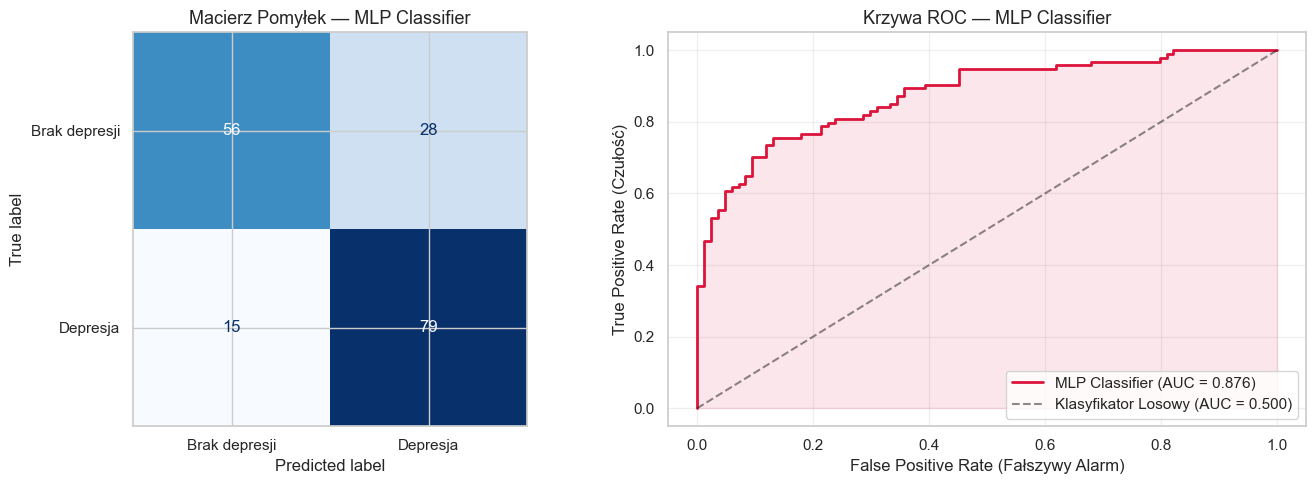


Wynik AUC dla MLP = 0.876


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_pred_mlp = pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_mlp)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Brak depresji', 'Depresja'])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Macierz Pomyłek — MLP Classifier', fontsize=13)

y_scores_mlp = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores_mlp)
roc_auc = auc(fpr, tpr)

# Rysowanie krzywej ROC (używamy koloru crimson/czerwonego dla spójności z MLP)
axes[1].plot(fpr, tpr, color='crimson', linewidth=2, label=f'MLP Classifier (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Klasyfikator Losowy (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='crimson')

axes[1].set_xlabel('False Positive Rate (Fałszywy Alarm)')
axes[1].set_ylabel('True Positive Rate (Czułość)')
axes[1].set_title('Krzywa ROC — MLP Classifier', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# Wyświetlenie całości
plt.tight_layout()
plt.show()

print(f"\nWynik AUC dla MLP = {roc_auc:.3f}")

#### Podsumowując lepszy jest model MLP

## Szukanie najlepszego modelu MLP

In [74]:
mlp_base = MLPClassifier(
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', mlp_base)
])

# 3. Konfiguracja GridSearchCV (szukamy najlepszych parametrów)
param_grid = {
    'model__hidden_layer_sizes': [(64,), (32, 16), (64, 32)], # Różne architektury sieci
    'model__activation': ['relu', 'tanh'],                    # Funkcje aktywacji
    'model__alpha': [0.0001, 0.01],                           # Regularyzacja
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='recall', # Optymalizujemy pod kątem wyłapywania chorych
    n_jobs=-1
)

# Trenujemy setki kombinacji
grid_search.fit(X_train, y_train)

# Zapisujemy najlepszy znaleziony model
best_pipeline = grid_search.best_estimator_

y_pred_best = best_pipeline.predict(X_test)
y_probs_best = best_pipeline.predict_proba(X_test)[:, 1]

# --- Raport Klasyfikacji ---
print("\n=== Szczegółowy Raport Klasyfikacji (Zoptymalizowane MLP) ===\n")
print(classification_report(y_test, y_pred_best, target_names=['Brak depresji', 'Depresja']))


=== Szczegółowy Raport Klasyfikacji (Zoptymalizowane MLP) ===

               precision    recall  f1-score   support

Brak depresji       0.76      0.65      0.71        84
     Depresja       0.73      0.82      0.77        94

     accuracy                           0.74       178
    macro avg       0.75      0.74      0.74       178
 weighted avg       0.74      0.74      0.74       178



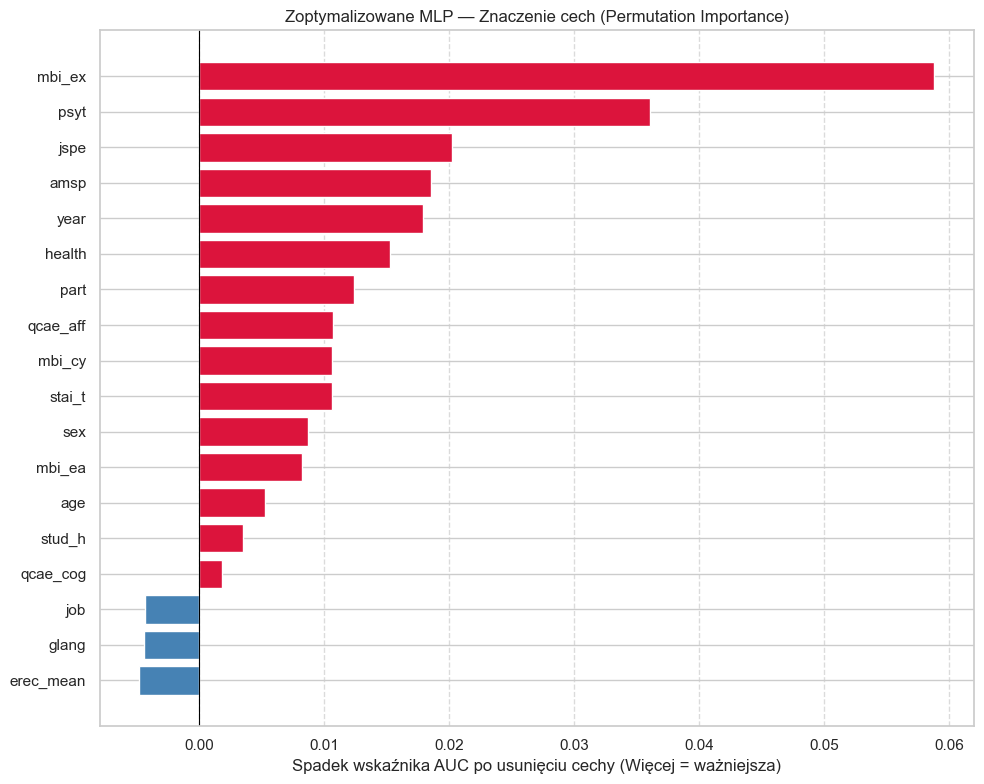

In [75]:
importance = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

mlp_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': importance.importances_mean
}).sort_values('Importance')

plt.figure(figsize=(10, 8))
colors = ['steelblue' if w < 0 else 'crimson' for w in mlp_importance_df['Importance']]

plt.barh(mlp_importance_df['Feature'], mlp_importance_df['Importance'], color=colors)
plt.xlabel('Spadek wskaźnika AUC po usunięciu cechy (Więcej = ważniejsza)')
plt.title('Zoptymalizowane MLP — Znaczenie cech (Permutation Importance)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

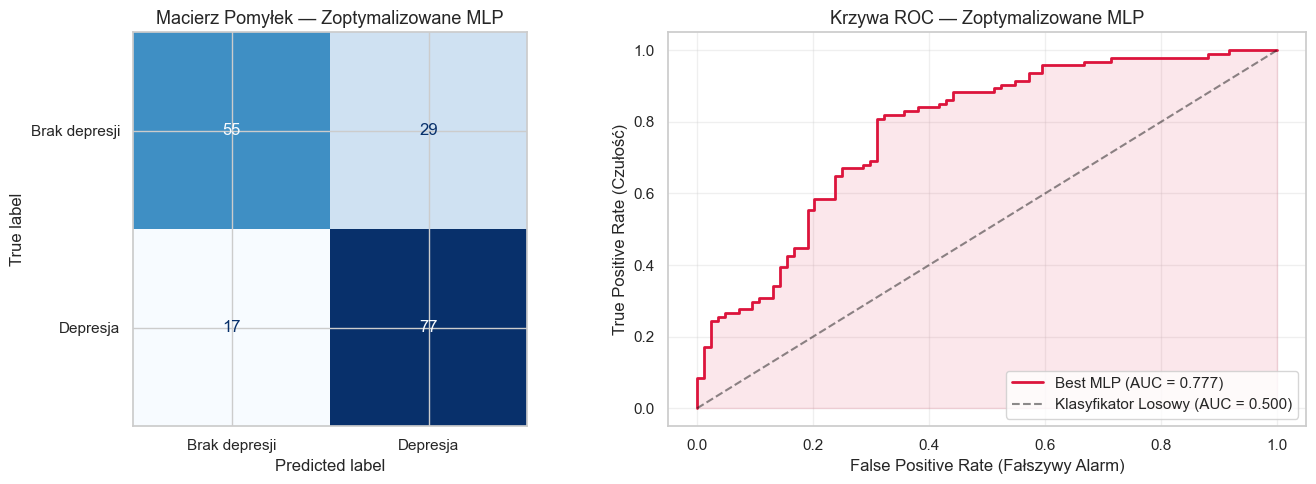

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Brak depresji', 'Depresja'])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Macierz Pomyłek — Zoptymalizowane MLP', fontsize=13)

# Wykres 2: Krzywa ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_best)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='crimson', linewidth=2, label=f'Best MLP (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Klasyfikator Losowy (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='crimson')

axes[1].set_xlabel('False Positive Rate (Fałszywy Alarm)')
axes[1].set_ylabel('True Positive Rate (Czułość)')
axes[1].set_title('Krzywa ROC — Zoptymalizowane MLP', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()